In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号 #有中文出现的情况，需要u'内容'

In [14]:
df=pd.read_excel('共享单车数据十万条1.xls') #读取数据

In [15]:
df

,Unnamed: 0,trip_id,骑行时间,开始时间,结束时间,开始站点id,开始经度,开始维度,结束站点,结束经度,结束维度,车辆id,会员骑行时间,骑行路线类别,会员类型
0,1,33404951,36,7/1/2020 0:09,7/1/2020 0:45,3018,39.043732,116.260139,3018,39.043732,116.260139,5996,0,Round Trip,Walk-up
1,2,33404950,13,7/1/2020 0:10,7/1/2020 0:23,3055,39.044159,116.251579,3082,39.046520,116.237411,5777,0,One Way,Walk-up
2,3,33404947,34,7/1/2020 0:11,7/1/2020 0:45,3018,39.043732,116.260139,3018,39.043732,116.260139,6342,0,Round Trip,Walk-up
3,4,33404948,34,7/1/2020 0:11,7/1/2020 0:45,3018,39.043732,116.260139,3018,39.043732,116.260139,6478,0,Round Trip,Walk-up
4,5,33404949,12,7/1/2020 0:11,7/1/2020 0:23,3055,39.044159,116.251579,3082,39.046520,116.237411,6411,0,One Way,Walk-up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65530,65531,47674698,6,9/23/2020 3:02,9/23/2020 3:08,3052,39.051102,116.264557,3055,39.044159,116.251579,6138,30,One Way,Monthly Pass
65531,65532,47674697,3,9/23/2020 3:31,9/23/2020 3:34,4215,39.014309,116.491341,4215,39.014309,116.491341,12394,0,Round Trip,Walk-up
65532,65533,47682850,77,9/23/2020 3:32,9/23/2020 4:49,4215,39.014309,116.491341,4209,38.996239,116.477448,11999,0,One Way,Walk-up
65533,65534,47674696,3,9/23/2020 3:38,9/23/2020 3:41,3005,39.048500,116.258537,3031,39.044701,116.252441,6434,30,One Way,Monthly Pass


In [16]:
cat=pd.get_dummies(df[['骑行路线类别','会员类型']])  #onehot编码
cat

,骑行路线类别_One Way,骑行路线类别_Round Trip,会员类型_Flex Pass,会员类型_Monthly Pass,会员类型_Walk-up
0,0,1,0,0,1
1,1,0,0,0,1
2,0,1,0,0,1
3,0,1,0,0,1
4,1,0,0,0,1
...,...,...,...,...,...
65530,1,0,0,1,0
65531,0,1,0,0,1
65532,1,0,0,0,1
65533,1,0,0,1,0


In [20]:
data=pd.concat([df['开始时间'].apply(pd.to_datetime).apply(lambda x:x.replace(minute=0)) ,cat],axis=1)
data['count']=1
data

,开始时间,骑行路线类别_One Way,骑行路线类别_Round Trip,会员类型_Flex Pass,会员类型_Monthly Pass,会员类型_Walk-up,count
0,2020-07-01 00:00:00,0,1,0,0,1,1
1,2020-07-01 00:00:00,1,0,0,0,1,1
2,2020-07-01 00:00:00,0,1,0,0,1,1
3,2020-07-01 00:00:00,0,1,0,0,1,1
4,2020-07-01 00:00:00,1,0,0,0,1,1
...,...,...,...,...,...,...,...
65530,2020-09-23 03:00:00,1,0,0,1,0,1
65531,2020-09-23 03:00:00,0,1,0,0,1,1
65532,2020-09-23 03:00:00,1,0,0,0,1,1
65533,2020-09-23 03:00:00,1,0,0,1,0,1


In [21]:
data.groupby('开始时间').sum()

,骑行路线类别_One Way,骑行路线类别_Round Trip,会员类型_Flex Pass,会员类型_Monthly Pass,会员类型_Walk-up,count
开始时间,,,,,,
2020-07-01 00:00:00,10,4,0,7,7,14
2020-07-01 01:00:00,10,1,0,3,8,11
2020-07-01 02:00:00,7,0,0,2,5,7
2020-07-01 03:00:00,4,0,0,2,2,4
2020-07-01 04:00:00,3,0,0,2,1,3
...,...,...,...,...,...,...
2020-09-23 00:00:00,18,3,0,10,11,21
2020-09-23 01:00:00,4,0,0,2,2,4
2020-09-23 02:00:00,10,0,1,4,5,10


<AxesSubplot:xlabel='开始时间'>

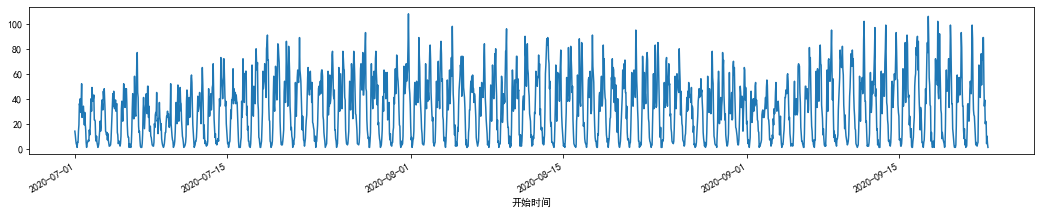

In [23]:
#魔法函数，inline表示图表嵌入到notebook中
%matplotlib inline
data.groupby('开始时间').sum()['count'].plot(figsize=(18,3))

In [29]:
#mean（）-->均值函数
data=pd.concat([data.groupby('开始时间').sum()['count'],data.groupby('开始时间').mean().drop(['count'],axis=1)],axis=1)

In [30]:
data

,count,骑行路线类别_One Way,骑行路线类别_Round Trip,会员类型_Flex Pass,会员类型_Monthly Pass,会员类型_Walk-up
开始时间,,,,,,
2020-07-01 00:00:00,14,0.714286,0.285714,0.0,0.500000,0.500000
2020-07-01 01:00:00,11,0.909091,0.090909,0.0,0.272727,0.727273
2020-07-01 02:00:00,7,1.000000,0.000000,0.0,0.285714,0.714286
2020-07-01 03:00:00,4,1.000000,0.000000,0.0,0.500000,0.500000
2020-07-01 04:00:00,3,1.000000,0.000000,0.0,0.666667,0.333333
...,...,...,...,...,...,...
2020-09-23 00:00:00,21,0.857143,0.142857,0.0,0.476190,0.523810
2020-09-23 01:00:00,4,1.000000,0.000000,0.0,0.500000,0.500000
2020-09-23 02:00:00,10,1.000000,0.000000,0.1,0.400000,0.500000


In [1]:
#标准化，求每个列中元素到最小值距离占该列最大值和最小值距离的比例
#归一化，默认0到1
from sklearn.preprocessing import MinMaxScaler
scale1=MinMaxScaler()
scale1.fit(np.array(data)[:,:1])
scalel

ModuleNotFoundError: No module named 'sklearn'

In [3]:
pip install sklearn

Note: you may need to restart the kernel to use updated packages.


In [45]:
scale=MinMaxScaler()
data=scale.fit_transform(data)

In [46]:
data_train=data[:1400,:]
data_val=data[1400:1600,:]
data_test=data[1600:,:]

In [47]:
def create_data(series,input_len):  #构造数据集
    X=[]
    Y=[]
    for i in range(len(series)-input_len):
        sig=series[i:i+input_len+1]
        X.append(sig[:input_len,:])
        Y.append(sig[-1,0])
    return np.array(X),np.array(Y)

In [52]:
X_train,Y_train=create_data(data_train,14)
X_val,Y_val=create_data(data_val,14)
X_test,Y_test=create_data(data_test,14)

In [53]:
X_train.shape

(1386, 14, 6)

In [15]:
# 构建模型
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense
from tensorflow.keras.layers import LSTM,LeakyReLU
from tensorflow.keras.layers import Dropout
model=Sequential()
model.add(LSTM(24,input_shape=(14,6)))
model.add(Dense(48))
model.add(LeakyReLU(alpha=0.2))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='RMSProp')

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24)                2976      
                                                                 
 dense (Dense)               (None, 48)                1200      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48)                0         
                                                                 
 dropout (Dropout)           (None, 48)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 49        
                                                                 
Total params: 4,225
Trainable params: 4,225
Non-trainable params: 0
_________________________________________________________________


Epoch 1/100

Epoch 1: val_loss improved from inf to 0.02177, saving model to lstm_model.h5
11/11 - 2s - loss: 0.0667 - val_loss: 0.0218 - 2s/epoch - 166ms/step
Epoch 2/100

Epoch 2: val_loss did not improve from 0.02177
11/11 - 0s - loss: 0.0373 - val_loss: 0.0218 - 62ms/epoch - 6ms/step
Epoch 3/100

Epoch 3: val_loss did not improve from 0.02177
11/11 - 0s - loss: 0.0349 - val_loss: 0.0222 - 64ms/epoch - 6ms/step
Epoch 4/100

Epoch 4: val_loss did not improve from 0.02177
11/11 - 0s - loss: 0.0314 - val_loss: 0.0219 - 60ms/epoch - 5ms/step
Epoch 5/100

Epoch 5: val_loss improved from 0.02177 to 0.01588, saving model to lstm_model.h5
11/11 - 0s - loss: 0.0282 - val_loss: 0.0159 - 68ms/epoch - 6ms/step
Epoch 6/100

Epoch 6: val_loss improved from 0.01588 to 0.01517, saving model to lstm_model.h5
11/11 - 0s - loss: 0.0264 - val_loss: 0.0152 - 67ms/epoch - 6ms/step
Epoch 7/100

Epoch 7: val_loss did not improve from 0.01517
11/11 - 0s - loss: 0.0244 - val_loss: 0.0190 - 59ms/epoch - 5ms/s

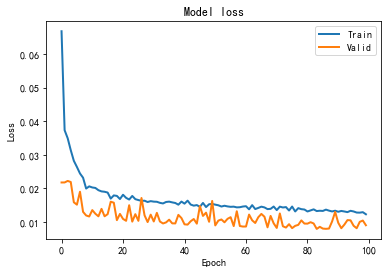

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint,TensorBoard
cp= ModelCheckpoint(filepath="lstm_model.h5",
                               save_best_only=True,
                               verbose=1)

tb = TensorBoard(log_dir='./logs',
                histogram_freq=10,
                write_graph=True,
                write_images=True)


history = model.fit(X_train, Y_train, epochs=100, 
                    batch_size=128, 
                    validation_data=(X_val,Y_val),
                    verbose=2, callbacks=[cp, tb]).history
                                                
plt.plot(history['loss'], linewidth=2, label='Train')
plt.plot(history['val_loss'], linewidth=2, label='Valid')
plt.legend(loc='upper right')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [18]:
from tensorflow.keras.models import load_model
model=load_model("lstm_model.h5")

In [19]:
Y_pred=model(X_test)

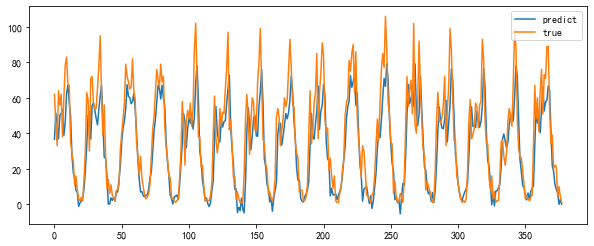

In [20]:
plt.figure(figsize=(10,4))
plt.plot(scale1.inverse_transform(Y_pred),label='predict')
plt.plot(scale1.inverse_transform(Y_test.reshape(-1,1)),label='true')
plt.legend()

In [33]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mse=mean_squared_error(scale1.inverse_transform(Y_pred),scale1.inverse_transform(Y_test.reshape(-1,1)))
rmse=mse**0.5
mae=mean_absolute_error(scale1.inverse_transform(Y_pred),scale1.inverse_transform(Y_test.reshape(-1,1)))
r2=r2_score(scale1.inverse_transform(Y_test.reshape(-1,1)).flatten(),scale1.inverse_transform(Y_pred).flatten())

In [34]:
print('rmse:{},mae:{},r2:{}'.format(rmse,mae,r2))

rmse:14.655426160805069,mae:10.928687388402603,r2:0.7159050401098432
